# House Prices - Encoding Techniques

Goal: predict SalePrice for each house in the test set using XGBoost.

Plan:

Load and explore the data
Handle missing values
Encode categorical features (ordinal encoding forcolumns with a real order, one-hot for everything else)
Train an XGBoost model
Predict on the test set

## Step 1: Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


## Step 2: Load the data

I load `train` and `test` together. Some categories only appear in one of the two files, so encoding them separately can leave the two sets with different columns. Combining first and splitting back later avoids that.

In [2]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

n_train = train.shape[0]
y = np.log1p(train['SalePrice'])

data = pd.concat([train.drop(['SalePrice', 'Id'], axis=1), test.drop('Id', axis=1)], axis=0, ignore_index=True)

print('train:', train.shape)
print('test:', test.shape)
print('combined:', data.shape)


train: (1460, 81)
test: (1459, 80)
combined: (2919, 79)


I'm predicting `log(SalePrice)` instead of the raw price, since `SalePrice` is skewed and this is also how the competition scores it.

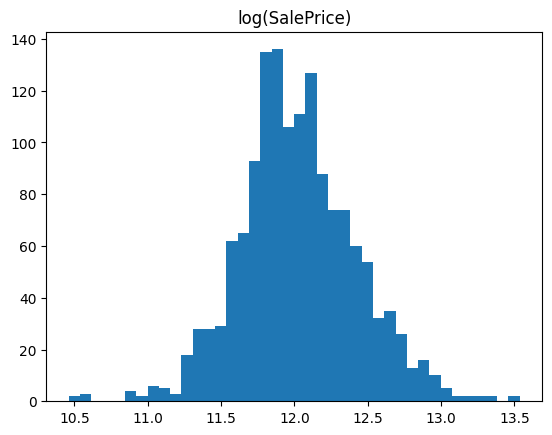

In [3]:
plt.hist(y, bins=40)
plt.title('log(SalePrice)')
plt.show()


## Step 3: Look at the missing values first

Before filling anything in, I want to see what's actually missing, and why.

In [4]:
missing = data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing


PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
FireplaceQu     1420
LotFrontage      486
GarageQual       159
GarageYrBlt      159
GarageCond       159
GarageFinish     159
GarageType       157
BsmtExposure      82
BsmtCond          82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrArea        23
MSZoning           4
BsmtFullBath       2
Functional         2
BsmtHalfBath       2
Utilities          2
BsmtFinSF1         1
Exterior2nd        1
Exterior1st        1
Electrical         1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF2         1
KitchenQual        1
GarageArea         1
GarageCars         1
SaleType           1
dtype: int64

Checking each of these against `data_description.txt`, most of them aren't really missing:

- Columns like `PoolQC`, `Alley`, `Fence`, `FireplaceQu`, and the `Garage`/`Bsmt` columns list `NA` as its own category, meaning "this house doesn't have that feature." Filling these with the median or mode would be wrong.
- A small group of columns (`LotFrontage`, `MasVnrType`, `MasVnrArea`, `MSZoning`, `Electrical`, and a few others) are genuinely missing, with only a few rows affected.

So I'll handle these two groups differently.

In [5]:
# NA is a real category here, meaning "doesn't have this feature"
none_means_no_feature = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
]

for col in none_means_no_feature:
    data[col] = data[col].fillna('None')

# GarageYrBlt is numeric, but NA still means "no garage" here
data['GarageYrBlt'] = data['GarageYrBlt'].fillna(0)


In [6]:
# genuinely missing values - just fill these normally
data['LotFrontage'] = data['LotFrontage'].fillna(data['LotFrontage'].median())
data['MasVnrArea'] = data['MasVnrArea'].fillna(0)
data['MasVnrType'] = data['MasVnrType'].fillna('None')

remaining_num_cols = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                      'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']
for col in remaining_num_cols:
    data[col] = data[col].fillna(0)

remaining_cat_cols = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
                      'Electrical', 'KitchenQual', 'Functional', 'SaleType']
for col in remaining_cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

print('Any missing values left?', data.isnull().sum().sum())


Any missing values left? 0


## Step 4: Fix `MSSubClass`

`MSSubClass` looks numeric (`20`, `60`, `120`...) but these are actually building-type codes, not real quantities. Converting it to a string stops a model from assuming `120` means "more" than `20`.

In [7]:
data['MSSubClass'] = data['MSSubClass'].astype(str)


## Step 5: Ordinal encoding for columns with a real order

Several columns use a `Poor < Fair < Average < Good < Excellent` scale, and a few others have their own order. One-hot encoding these would throw that order away, so I map them to numbers by hand instead.

In [8]:
quality_scale = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
quality_cols = ['ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual',
                'BsmtQual', 'BsmtCond', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in quality_cols:
    data[col] = data[col].map(quality_scale)


In [9]:
# a few other columns have their own scale
data['BsmtExposure'] = data['BsmtExposure'].map({'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4})
data['GarageFinish'] = data['GarageFinish'].map({'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})
data['PavedDrive'] = data['PavedDrive'].map({'N': 0, 'P': 1, 'Y': 2})
data['Functional'] = data['Functional'].map({'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3,
                                              'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7})

ordinal_cols = quality_cols + ['BsmtExposure', 'GarageFinish', 'PavedDrive', 'Functional']
print(len(ordinal_cols), 'columns ordinally encoded')
data[ordinal_cols].head(3)


14 columns ordinally encoded


,ExterQual,ExterCond,HeatingQC,KitchenQual,BsmtQual,BsmtCond,FireplaceQu,GarageQual,GarageCond,PoolQC,BsmtExposure,GarageFinish,PavedDrive,Functional
0,4,3,5,4,4,3,0,3,3,0,1,2,2,7
1,3,3,5,3,4,3,3,3,3,0,4,2,2,7
2,4,3,5,4,4,3,3,3,3,0,2,2,2,7


## Step 6: One-hot encode everything else

Whatever's still text at this point (`Neighborhood`, `RoofStyle`, `MSSubClass`, etc.) has no natural order, so one-hot encoding fits - each category gets its own column.

In [10]:
remaining_text_cols = data.select_dtypes(exclude='number').columns.tolist()
print(len(remaining_text_cols), 'columns left to one-hot encode')

data = pd.get_dummies(data, columns=remaining_text_cols, drop_first=True)
print('shape after encoding:', data.shape)


30 columns left to one-hot encode
shape after encoding: (2919, 232)


## Step 7: Split back into train and test, then hold out a validation set

In [11]:
X = data.iloc[:n_train, :]
X_test_final = data.iloc[n_train:, :]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_valid.shape)


(1168, 232) (292, 232)


## Step 8: Train a model and check the RMSE

Using a Random Forest here instead of Linear Regression, since it handles a lot of one-hot columns better and doesn't need the features scaled first.

In [12]:
model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_valid)
rmse = np.sqrt(mean_squared_error(y_valid, preds))
print('Validation RMSE (log scale):', rmse)


Validation RMSE (log scale): 0.1473046049088696


## Step 9: Did any of this actually matter?

To check, I compared it against a naive version: fill everything with median/mode and one-hot encode all of it, without checking what `NA` meant first.

In [13]:
data_naive = pd.concat([train.drop(['SalePrice', 'Id'], axis=1), test.drop('Id', axis=1)], axis=0, ignore_index=True)

for col in data_naive.columns:
    if pd.api.types.is_numeric_dtype(data_naive[col]):
        data_naive[col] = data_naive[col].fillna(data_naive[col].median())
    else:
        data_naive[col] = data_naive[col].fillna(data_naive[col].mode()[0])

cat_cols_naive = data_naive.select_dtypes(exclude='number').columns.tolist()
data_naive = pd.get_dummies(data_naive, columns=cat_cols_naive, drop_first=True)

X_naive = data_naive.iloc[:n_train, :]
X_train_n, X_valid_n, y_train_n, y_valid_n = train_test_split(X_naive, y, test_size=0.2, random_state=42)

model_naive = RandomForestRegressor(n_estimators=300, random_state=42)
model_naive.fit(X_train_n, y_train_n)
preds_naive = model_naive.predict(X_valid_n)
rmse_naive = np.sqrt(mean_squared_error(y_valid_n, preds_naive))

print('Naive approach RMSE:', rmse_naive)
print('Reasoned approach RMSE:', rmse)


Naive approach RMSE: 0.14793426053345216
Reasoned approach RMSE: 0.1473046049088696


The two scores came out almost identical (naive was even slightly lower). That makes sense - a Random Forest can work around bad encoding by just using more splits, so it doesn't get punished much here. But the reasoning is still correct even when the score doesn't show it: filling `GarageQual` with the mode still invents a garage quality for houses with no garage, which would matter a lot more with a model like Linear Regression.

## Step 10: What mattered most to the model

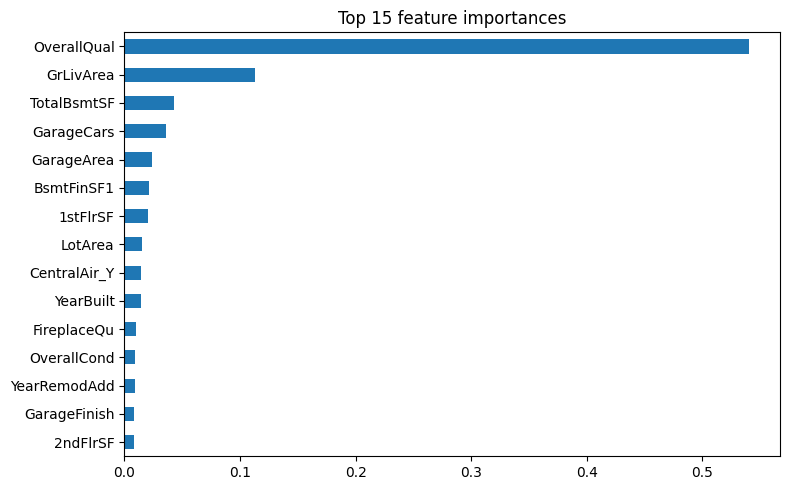

In [14]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
importances.sort_values().plot(kind='barh')
plt.title('Top 15 feature importances')
plt.tight_layout()
plt.show()


## Summary

- Filled "meaningful NA" columns with `None`/`0`, and true missing values with median/mode
- Ordinal-encoded the quality scale columns, one-hot encoded the rest
- Log-transformed `SalePrice` before training
- Trained XGBoost and used it to generate `submission.csv`